# Residual Assumption Diagnostics

Regression inference depends on assumptions about the random errors. This notebook focuses on what can be checked from residuals and what each check means.

By the end of this notebook, you should be able to:

- connect residual plots to mean-zero and constant-variance assumptions;
- use Q-Q plots and normality tests as supporting evidence rather than automatic decisions;
- compute Durbin-Watson for serial correlation;
- explain when a transformation or model change may be needed.

In [1]:
from lite_setup import ensure_packages
await ensure_packages()

Running outside JupyterLite; assuming packages are already installed.


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

process = pd.read_csv(Path('data/process_diagnostics.csv'))
model = smf.ols('YieldLoss ~ Temperature + LineSpeed + Pressure', data=process).fit()
resid = model.resid
fitted = model.fittedvalues
print(model.summary().tables[0])

                            OLS Regression Results                            
Dep. Variable:              YieldLoss   R-squared:                       0.360
Model:                            OLS   Adj. R-squared:                  0.322
Method:                 Least Squares   F-statistic:                     9.556
Date:                Mon, 18 May 2026   Prob (F-statistic):           4.11e-05
Time:                        01:54:35   Log-Likelihood:                -222.16
No. Observations:                  55   AIC:                             452.3
Df Residuals:                      51   BIC:                             460.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         


## Residuals and the Error Assumptions

The ideal error model is $\epsilon_i \sim N(0, \sigma^2)$ with independent errors. In practice, use diagnostics to ask:

- Mean zero: do residuals center around zero over the fitted range?
- Constant variance: does residual spread stay roughly stable?
- Normality: are residuals approximately normal when using t/F inference in small samples?
- Independence: are residuals correlated in time, space, or collection order?

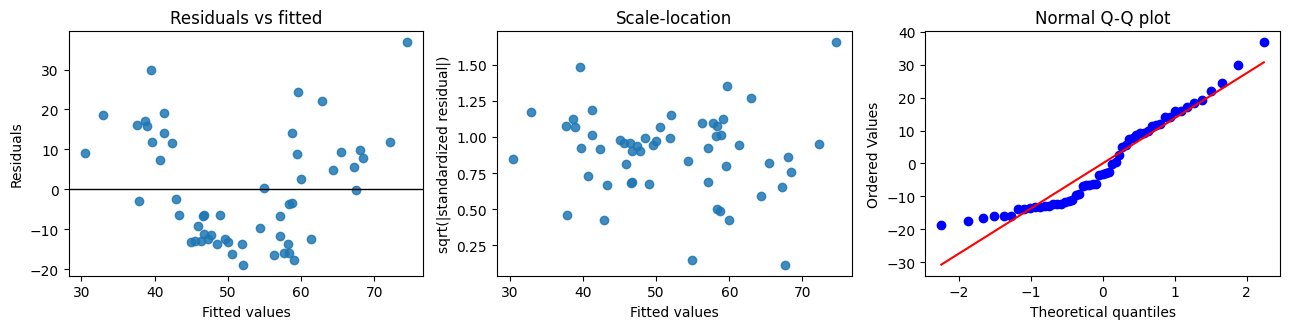

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
axes[0].scatter(fitted, resid, alpha=0.85)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs fitted')

axes[1].scatter(fitted, np.sqrt(np.abs(model.get_influence().summary_frame()['standard_resid'])), alpha=0.85)
axes[1].set_xlabel('Fitted values')
axes[1].set_ylabel('sqrt(|standardized residual|)')
axes[1].set_title('Scale-location')

stats.probplot(resid, dist='norm', plot=axes[2])
axes[2].set_title('Normal Q-Q plot')
plt.tight_layout()

Interpretation: curvature in residuals suggests the mean function may be misspecified. A funnel shape suggests nonconstant variance. Strong Q-Q plot departures suggest normal-based small-sample inference may be fragile.

In [4]:
bp_lm, bp_lm_pvalue, bp_f, bp_f_pvalue = het_breuschpagan(resid, model.model.exog)
print(f'Breusch-Pagan LM p-value: {bp_lm_pvalue:.4f}')
print(f'Breusch-Pagan F p-value:  {bp_f_pvalue:.4f}')
print('Small p-values suggest nonconstant variance.')

Breusch-Pagan LM p-value: 0.6499
Breusch-Pagan F p-value:  0.6684
Small p-values suggest nonconstant variance.


## Durbin-Watson for Independence

Durbin-Watson is often used when observations have a natural order. Values near 2 are consistent with little first-order autocorrelation. Values below 2 suggest positive autocorrelation; values above 2 suggest negative autocorrelation.

Durbin-Watson statistic: 1.164


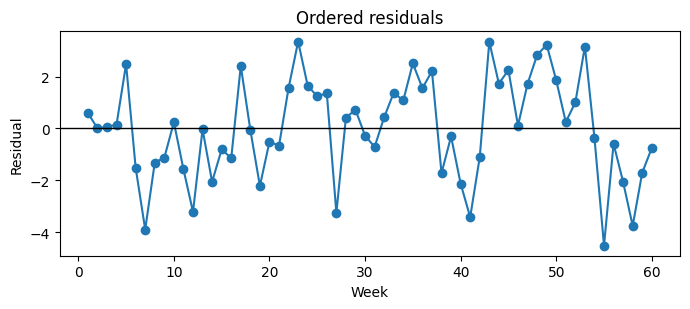

In [5]:
auto = pd.read_csv(Path('data/autocorrelated_process.csv'))
auto_model = smf.ols('EnergyUse ~ Load', data=auto).fit()
dw = durbin_watson(auto_model.resid)
print(f'Durbin-Watson statistic: {dw:.3f}')

plt.figure(figsize=(7, 3.2))
plt.plot(auto['Week'], auto_model.resid, marker='o')
plt.axhline(0, color='black', linewidth=1)
plt.xlabel('Week')
plt.ylabel('Residual')
plt.title('Ordered residuals')
plt.tight_layout()

## Added-Variable and Component-Plus-Residual Plots

The software notes also use added-variable, component-plus-residual, and related plots to diagnose whether a predictor's contribution is roughly linear after accounting for the other predictors. These plots answer a different question from a residual-vs-fitted plot: they focus on one predictor at a time while holding the rest of the model in the background.

Use these as model-form checks. Curvature or isolated points in these plots suggests that you should consider transformation, interaction, nonlinear terms, or data-quality review before trusting the fitted model.

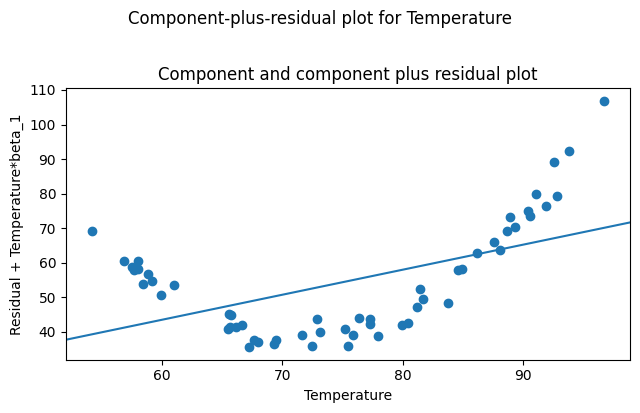

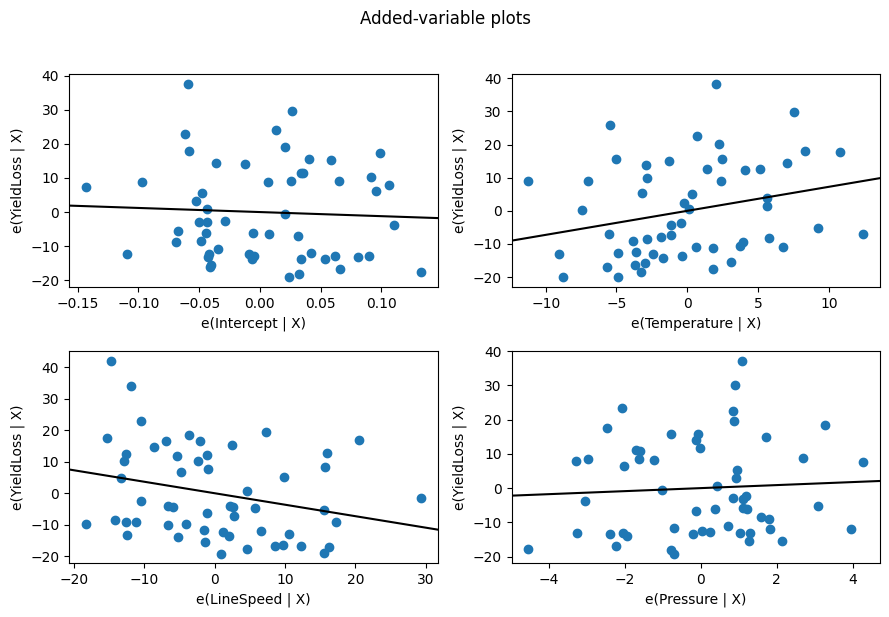

In [6]:
fig = sm.graphics.plot_ccpr(model, 'Temperature')
fig.set_size_inches(6.5, 4)
fig.suptitle('Component-plus-residual plot for Temperature', y=1.02)
plt.tight_layout()

fig = sm.graphics.plot_partregress_grid(model)
fig.set_size_inches(9, 6)
fig.suptitle('Added-variable plots', y=1.02)
plt.tight_layout()

## What to Do When Diagnostics Fail

A diagnostic concern should lead to a modeling action, not just a label. Common actions include adding a missing nonlinear term, transforming the response, modeling the variance, adding omitted predictors, using a time-series error structure, checking data quality, or narrowing the intended prediction region.

Transfer question: if residuals fan out as fitted values increase, what would change in your interpretation of prediction intervals?